# Disease Prediction — Comparative Model Analysis (Aakash)
### Primary: XGBoost & K-Nearest Neighbors & Logistic Regression 

---

**How this notebook is structured:**

| Section | Description |
|---|---|
| 1–3 | Imports, data loading, preprocessing (shared — run once) |
| 4 | Model registry |
| 5 | Training & evaluation engine (runs all registered models automatically) |
| 6 | Results table |
| 7 | Comparison visualizations |
| 8 | Deep-dive: XGBoost (feature importance + SHAP) |
| 9 | Deep-dive: KNN (K tuning + decision boundary analysis) |
| 10 | Confusion matrices per model |
| 11 | Final summary |

## 1. Imports

In [15]:

import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Preprocessing & utilities
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    cross_validate, StratifiedKFold, GridSearchCV
)
from sklearn.feature_selection import mutual_info_classif

# Models — core
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

# Models 
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.naive_bayes     import BernoulliNB
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import LinearSVC
from sklearn.neural_network  import MLPClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

# Interpretability
import shap

# Output folder
os.makedirs('results', exist_ok=True)

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('All imports successful.')

All imports successful.


## 2. Load & Inspect Data

In [16]:
# Paths for dataset (# make sure the cwd is "Disease_Prediction_With_ML")

TRAIN_PATH = '../data/raw/Training.csv'
TEST_PATH  = '../data/raw/Testing.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

# Drop unnamed trailing columns if present
train_df = train_df.loc[:, ~train_df.columns.str.contains('^Unnamed')]
test_df  = test_df.loc[:,  ~test_df.columns.str.contains('^Unnamed')]

print(f'Training : {train_df.shape[0]} rows × {train_df.shape[1]} columns')
print(f'Test     : {test_df.shape[0]}  rows × {test_df.shape[1]}  columns')
print(f'Missing values (train): {train_df.isnull().sum().sum()}')
print(f'Unique diseases        : {train_df["prognosis"].nunique()}')
train_df.head(3)

Training : 4920 rows × 133 columns
Test     : 42  rows × 133  columns
Missing values (train): 0
Unique diseases        : 41


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


## 3. Preprocessing

In [17]:
FEATURE_COLS = [c for c in train_df.columns if c != 'prognosis']
TARGET_COL   = 'prognosis'

X_train = train_df[FEATURE_COLS].values
X_test  = test_df[FEATURE_COLS].values

# Encode disease labels to integers
le = LabelEncoder()
y_train = le.fit_transform(train_df[TARGET_COL])
y_test  = le.transform(test_df[TARGET_COL])

N_CLASSES  = len(le.classes_)
N_FEATURES = len(FEATURE_COLS)

In [18]:
print(f'Train shape : {train_df.shape}')
print(f'Test shape  : {test_df.shape}')
print(f'Train unique diseases : {train_df["prognosis"].nunique()}')
print(f'Test unique diseases  : {test_df["prognosis"].nunique()}')
print(f'\nSmallest class in train: {pd.Series(y_train).value_counts().min()} samples')
print(f'Smallest class in test : {pd.Series(y_test).value_counts().min()} samples')

Train shape : (4920, 133)
Test shape  : (42, 133)
Train unique diseases : 41
Test unique diseases  : 41

Smallest class in train: 120 samples
Smallest class in test : 1 samples


In [19]:
# Auto-safe cross-validation — adjusts n_splits to the smallest class size
from collections import Counter

min_class_count = min(Counter(y_train).values())
n_splits = min(5, min_class_count)  # never exceed smallest class size

if n_splits < 5:
    print(f'Warning: smallest class has {min_class_count} samples — reducing to {n_splits}-fold CV')
else:
    print(f'Using {n_splits}-fold stratified CV')

CV = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

Using 5-fold stratified CV


---
## 4. Model Registry

**This is the only section that needs editing to add new models.**

Each entry follows this format:
```python
'Display Name': {
    'model' : <sklearn-compatible model instance>,
    'role'  : 'Baseline' | 'Core' | 'Comparison' | 'Bonus',
    'owner' : 'Your name or teammate name',
    'active': True   # set False to skip a model without deleting it
}
```
---

In [20]:
MODEL_REGISTRY = {


    'XGBoost': {
        'model': XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            eval_metric='mlogloss',
            tree_method='hist',
            random_state=42
        ),
        'role'  : 'Core — Boosting',
        'owner' : 'Your Name',
        'active': True
    },

    'KNN (k=5)': {
        'model': KNeighborsClassifier(
            n_neighbors=5,
            metric='euclidean',
            n_jobs=-1
        ),
        'role'  : 'Comparison',
        'owner' : 'Your Name',
        'active': True
    },

    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
        'role'  : 'Baseline',
        'owner' : 'Teammate A',
        'active': True
    }
}

# Only run models marked active=True
ACTIVE_MODELS = {k: v for k, v in MODEL_REGISTRY.items() if v['active']}
print(f'{len(ACTIVE_MODELS)} active model(s): {list(ACTIVE_MODELS.keys())}')

3 active model(s): ['XGBoost', 'KNN (k=5)', 'Logistic Regression']


## 5. Training & Evaluation Engine
> Runs automatically for every active model. No changes needed here.

In [21]:
def evaluate_model(name, entry, X_train, y_train, X_test, y_test, cv):
   # """Train a single model, run CV, evaluate on test set, return results dict."""
    model = entry['model']

    # --- 5-fold cross-validation ---
    cv_results = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        return_train_score=False, n_jobs=-1
    )

    # --- Full train + test evaluation ---
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = round(time.time() - t0, 3)

    y_pred = model.predict(X_test)

    return {
        'Model'                   : name,
        'CV Accuracy'             : cv_results['test_accuracy'].mean(),
        'CV Accuracy Std'         : cv_results['test_accuracy'].std(),
        'CV Macro F1'             : cv_results['test_f1_macro'].mean(),
        'CV Macro F1 Std'         : cv_results['test_f1_macro'].std(),
        'CV Weighted F1'          : cv_results['test_f1_weighted'].mean(),
        'Test Accuracy'           : accuracy_score(y_test, y_pred),
        'Test Macro F1'           : f1_score(y_test, y_pred, average='macro'),
        'Test Weighted F1'        : f1_score(y_test, y_pred, average='weighted'),
        'Test Precision'          : precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Test Recall'             : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'Train Time (s)'          : train_time,
        '_y_pred'                 : y_pred,   # stored for confusion matrix — not shown in table
    }


# Run all active models
all_results = []
for name, entry in ACTIVE_MODELS.items():
    print(f'  Running: {name} ...')
    result = evaluate_model(name, entry, X_train, y_train, X_test, y_test, CV)
    all_results.append(result)
    print(f'    Test Accuracy: {result["Test Accuracy"]*100:.2f}%  |  Macro F1: {result["Test Macro F1"]*100:.2f}%  |  Time: {result["Train Time (s)"]}s')

print('\nAll models evaluated.')

  Running: XGBoost ...
    Test Accuracy: 97.62%  |  Macro F1: 98.37%  |  Time: 5.991s
  Running: KNN (k=5) ...
    Test Accuracy: 100.00%  |  Macro F1: 100.00%  |  Time: 0.007s
  Running: Logistic Regression ...
    Test Accuracy: 100.00%  |  Macro F1: 100.00%  |  Time: 0.079s

All models evaluated.


## 6. Results Table

In [22]:
from pathlib import Path

# Specify the path for the new directory
directory_path = Path("../results/aakash_results")

# Create the directory (and any missing parent directories)
# parents=True creates intermediate directories if they don't exist
# exist_ok=True prevents an error if the directory already exists
try:
    directory_path.mkdir(parents=True, exist_ok=True)
    print(f"Directory '{directory_path}' created or already exists.")
except OSError as e:
    # Handle other potential OS errors (e.g., permission denied, invalid path)
    print(f"Error creating directory: {e}")

Directory '../results/aakash_results' created or already exists.


In [23]:
# Build results dataframe (drop internal prediction column)
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')} 
    for r in all_results
]).set_index('Model')

# Sort by Test Macro F1 descending
results_df = results_df.sort_values('Test Macro F1', ascending=False)

# Display formatted
display_df = results_df.copy()
pct_cols = ['CV Accuracy', 'CV Accuracy Std', 'CV Macro F1', 'CV Macro F1 Std',
            'CV Weighted F1', 'Test Accuracy', 'Test Macro F1', 'Test Weighted F1',
            'Test Precision', 'Test Recall']
for col in pct_cols:
    display_df[col] = display_df[col].map(lambda x: f'{x*100:.2f}%')

print('=== Results Summary — Sorted by Test Macro F1 ===')
print(display_df.to_string())


# Save raw results
results_df.to_csv('../results/aakash_results/model_comparison.csv')
print('\nSaved → results/aakash_results/model_comparison.csv')

=== Results Summary — Sorted by Test Macro F1 ===
                    CV Accuracy CV Accuracy Std CV Macro F1 CV Macro F1 Std CV Weighted F1 Test Accuracy Test Macro F1 Test Weighted F1 Test Precision Test Recall  Train Time (s)
Model                                                                                                                                                                             
KNN (k=5)               100.00%           0.00%     100.00%           0.00%        100.00%       100.00%       100.00%          100.00%        100.00%     100.00%           0.007
Logistic Regression     100.00%           0.00%     100.00%           0.00%        100.00%       100.00%       100.00%          100.00%        100.00%     100.00%           0.079
XGBoost                 100.00%           0.00%     100.00%           0.00%        100.00%        97.62%        98.37%           97.62%         98.78%      98.78%           5.991

Saved → results/aakash_results/model_comparison.csv


## 7. Comparison Visualizations
> All charts auto-scale to however many models are active.

In [24]:
# --- Shared colour palette (scales with model count) ---
n_models = len(results_df)
PALETTE  = sns.color_palette('Set2', max(n_models, 3))
model_names = list(results_df.index)

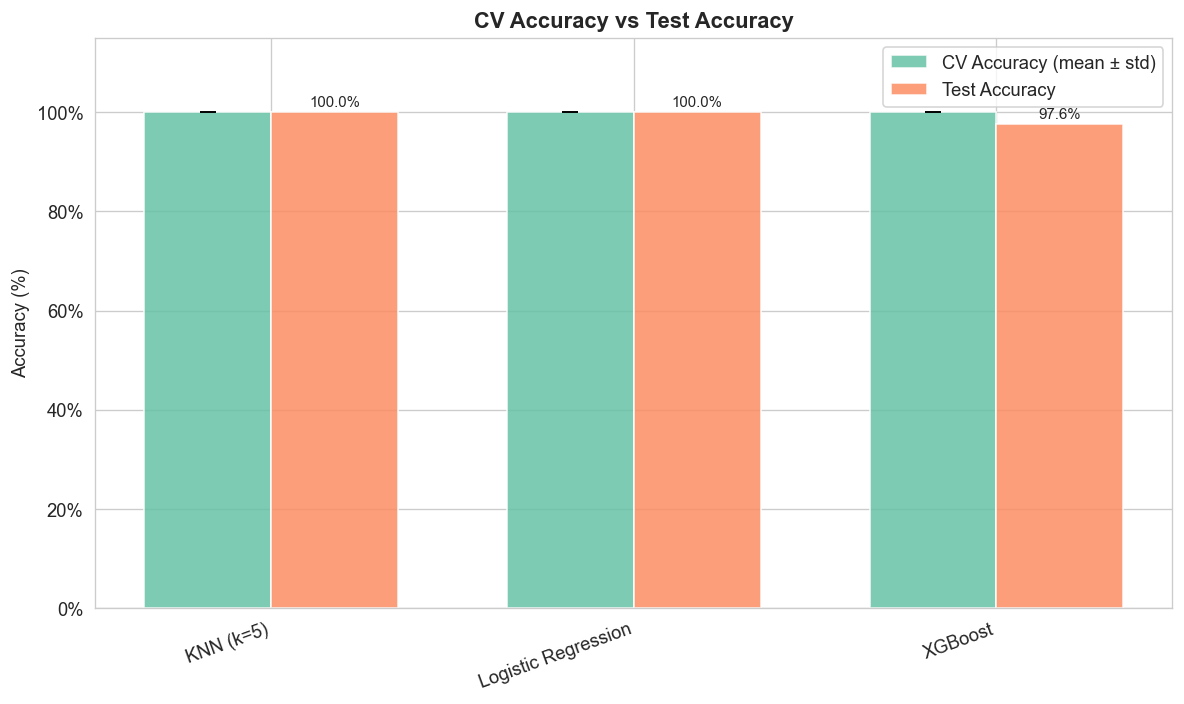

In [25]:
# --- 7.1 CV Accuracy vs Test Accuracy (grouped bar) ---
x     = np.arange(n_models)
width = 0.35

fig, ax = plt.subplots(figsize=(max(10, n_models * 1.5), 6))
ax.bar(x - width/2, results_df['CV Accuracy'] * 100, width,
       yerr=results_df['CV Accuracy Std'] * 100,
       label='CV Accuracy (mean ± std)', color=PALETTE[0], capsize=5, alpha=0.85)
ax.bar(x + width/2, results_df['Test Accuracy'] * 100, width,
       label='Test Accuracy', color=PALETTE[1], alpha=0.85)

for i, val in enumerate(results_df['Test Accuracy'] * 100):
    ax.text(i + width/2, val + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f%%'))
ax.set_title('CV Accuracy vs Test Accuracy', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../results/aakash_results/accuracy_comparison.png', bbox_inches='tight')
plt.show()

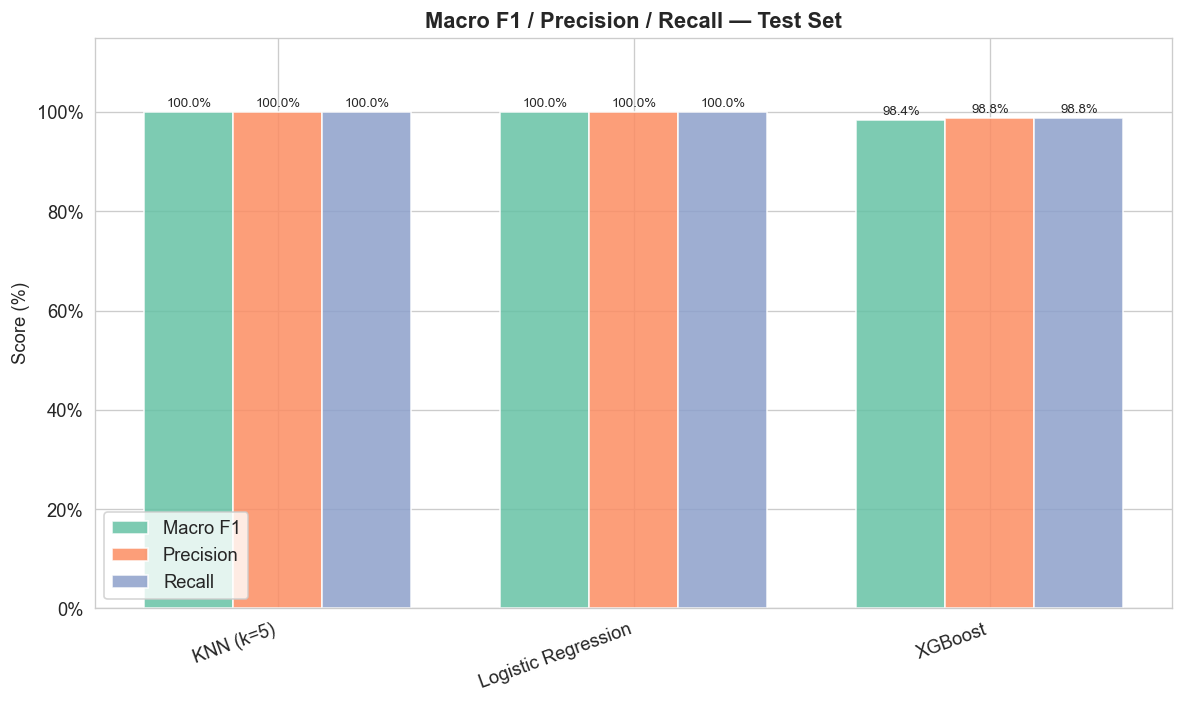

In [26]:
# --- 7.2 Macro F1 / Precision / Recall (grouped bar) ---
metrics = ['Test Macro F1', 'Test Precision', 'Test Recall']
labels  = ['Macro F1', 'Precision', 'Recall']

metric_palette = sns.color_palette('Set2', 3)  # always exactly 3 colours

x     = np.arange(n_models)
width = 0.25

fig, ax = plt.subplots(figsize=(max(10, n_models * 1.5), 6))
for i, (metric, label) in enumerate(zip(metrics, labels)):
    bars = ax.bar(
        x + (i - 1) * width,
        results_df[metric] * 100,
        width, label=label,
        color=metric_palette[i],   # 0, 1, 2 — never out of range
        alpha=0.85
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=8
        )

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Macro F1 / Precision / Recall — Test Set', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../results/aakash_results/f1_comparison.png', bbox_inches='tight')
plt.show()

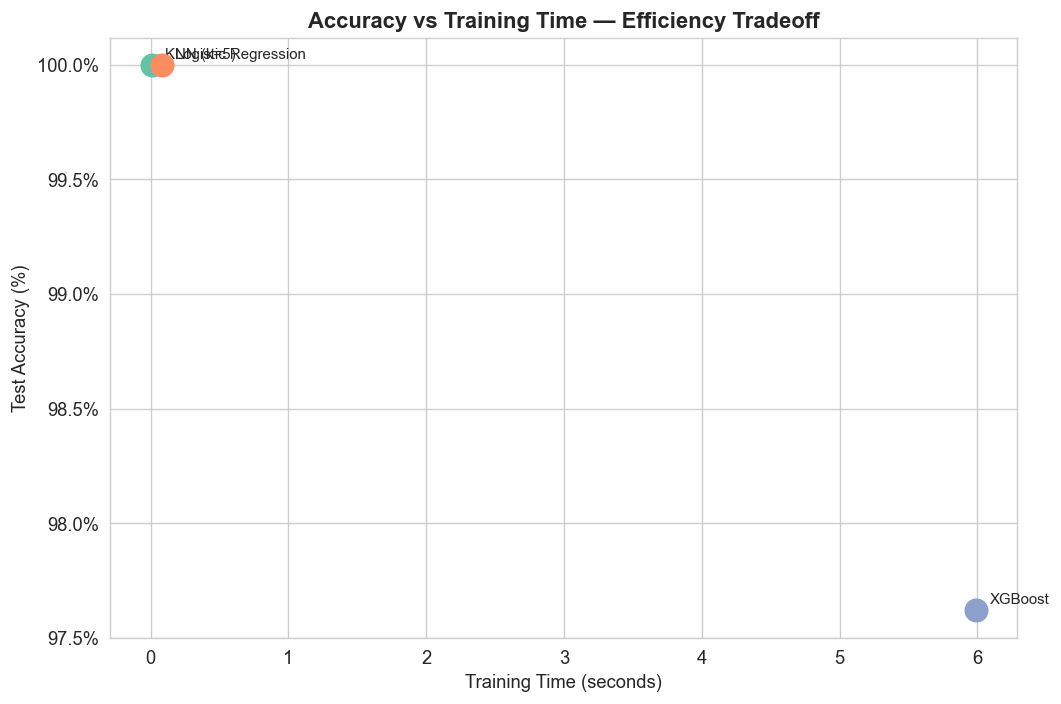

In [27]:
# --- 7.3 Accuracy vs Training Time (scatter) ---
fig, ax = plt.subplots(figsize=(9, 6))
for i, (name, row) in enumerate(results_df.iterrows()):
    ax.scatter(row['Train Time (s)'], row['Test Accuracy'] * 100,
               s=180, color=PALETTE[i], zorder=5, label=name)
    ax.annotate(name, (row['Train Time (s)'], row['Test Accuracy'] * 100),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

ax.set_xlabel('Training Time (seconds)')
ax.set_ylabel('Test Accuracy (%)')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))
ax.set_title('Accuracy vs Training Time — Efficiency Tradeoff', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/aakash_results/accuracy_vs_time.png', bbox_inches='tight')
plt.show()

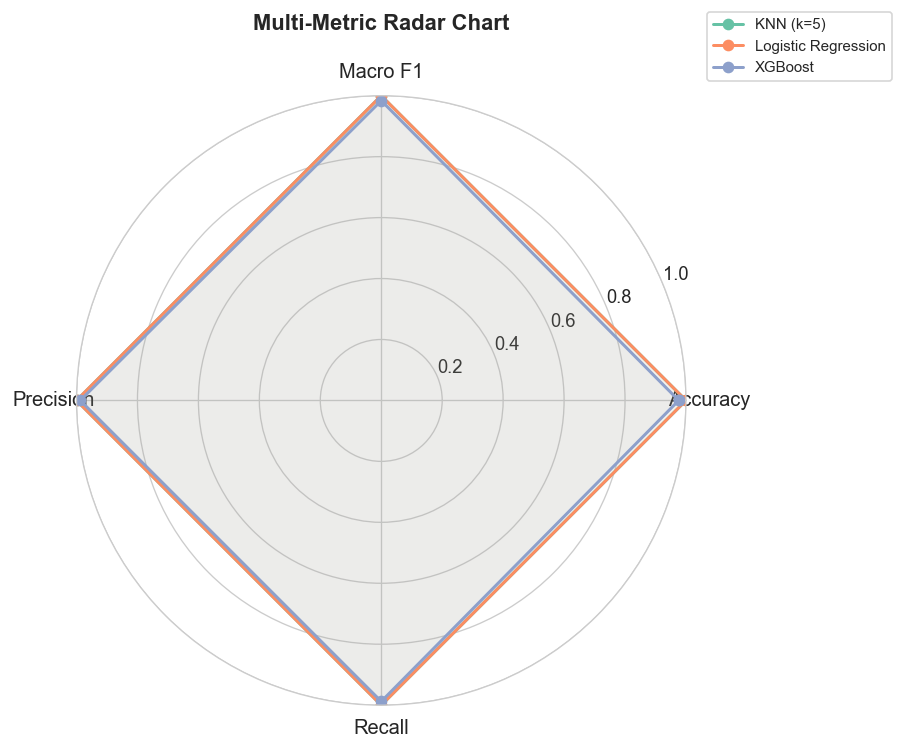

In [28]:
# --- 7.4 Radar chart (only renders meaningfully with 3+ models) ---
if n_models >= 3:
    radar_metrics = ['Test Accuracy', 'Test Macro F1', 'Test Precision', 'Test Recall']
    radar_labels  = ['Accuracy', 'Macro F1', 'Precision', 'Recall']
    N      = len(radar_metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for i, (name, row) in enumerate(results_df.iterrows()):
        values = [row[m] for m in radar_metrics] + [row[radar_metrics[0]]]
        ax.plot(angles, values, 'o-', linewidth=1.8, color=PALETTE[i], label=name)
        ax.fill(angles, values, alpha=0.07, color=PALETTE[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_title('Multi-Metric Radar Chart', fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
    plt.tight_layout()
    plt.savefig('../results/aakash_results/radar_chart.png', bbox_inches='tight')
    plt.show()
else:
    print('Radar chart will render once 3+ models are active.')

---
## 8. Deep-Dive: XGBoost
### 8.1 Hyperparameter Tuning (n_estimators × max_depth grid)

In [29]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

xgb_base = XGBClassifier(
    eval_metric='mlogloss', tree_method='hist', random_state=42
)

xgb_grid = GridSearchCV(
    xgb_base, param_grid, cv=CV,
    scoring='f1_macro', n_jobs=-1, verbose=1
)
xgb_grid.fit(X_train, y_train)

print(f'Best params : {xgb_grid.best_params_}')
print(f'Best CV F1  : {xgb_grid.best_score_*100:.2f}%')

# Evaluate best XGBoost on test
y_pred_xgb_best = xgb_grid.best_estimator_.predict(X_test)
print(f'Test Accuracy (tuned XGB): {accuracy_score(y_test, y_pred_xgb_best)*100:.2f}%')
print(f'Test Macro F1 (tuned XGB): {f1_score(y_test, y_pred_xgb_best, average="macro")*100:.2f}%')

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Best CV F1  : 100.00%
Test Accuracy (tuned XGB): 97.62%
Test Macro F1 (tuned XGB): 98.37%


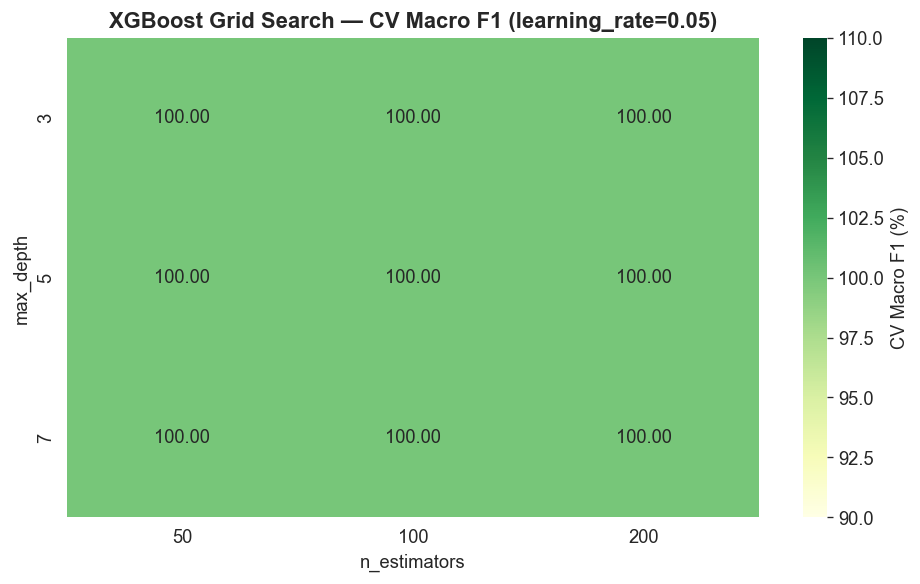

In [30]:
# --- Grid search heatmap: n_estimators vs max_depth (best learning_rate) ---
cv_results = pd.DataFrame(xgb_grid.cv_results_)
best_lr    = xgb_grid.best_params_['learning_rate']
pivot      = cv_results[
    cv_results['param_learning_rate'] == best_lr
].pivot_table(
    index='param_max_depth',
    columns='param_n_estimators',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot * 100, annot=True, fmt='.2f', cmap='YlGn', ax=ax,
            cbar_kws={'label': 'CV Macro F1 (%)'})
ax.set_title(f'XGBoost Grid Search — CV Macro F1 (learning_rate={best_lr})',
             fontweight='bold')
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.savefig('../results/aakash_results/xgb_gridsearch.png', bbox_inches='tight')
plt.show()

### 8.2 Feature Importance

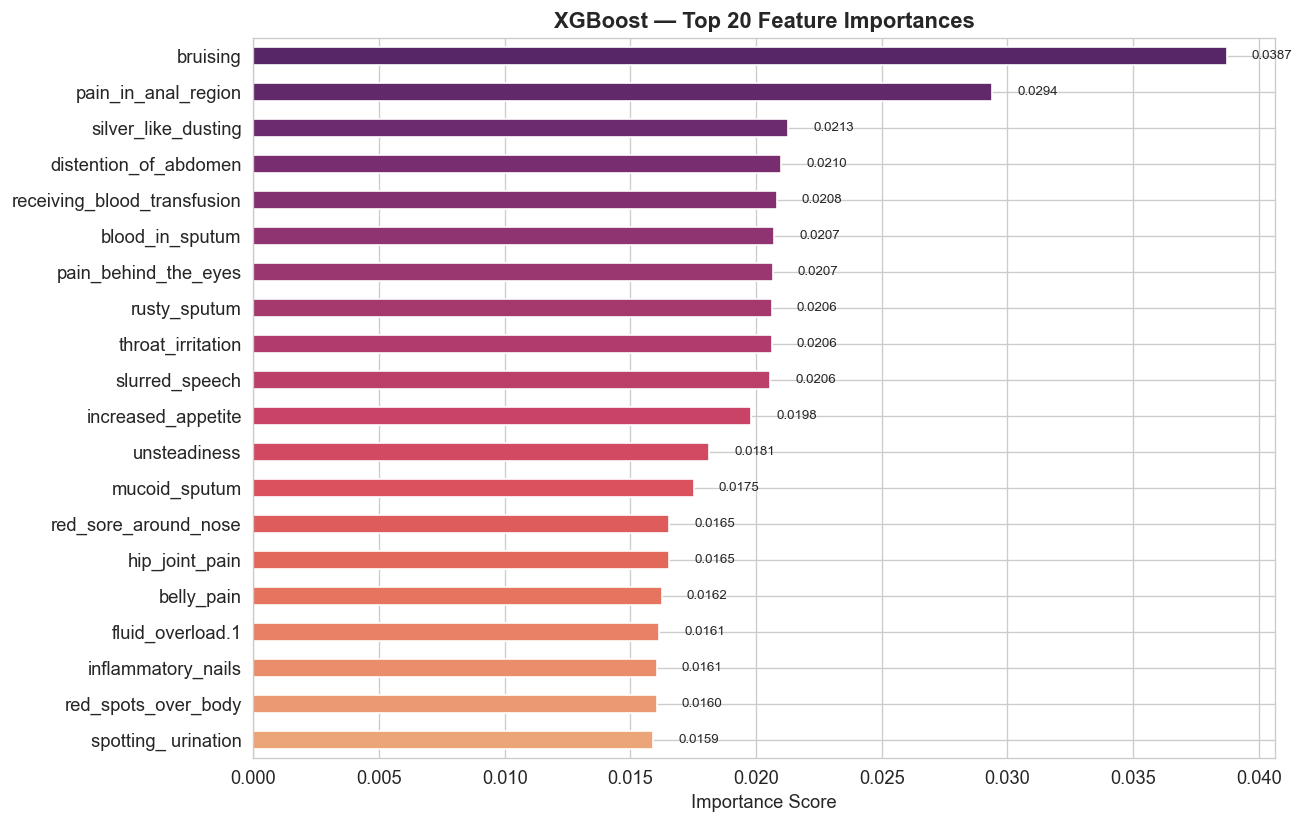

In [31]:
xgb_final = xgb_grid.best_estimator_
importances = pd.Series(xgb_final.feature_importances_, index=FEATURE_COLS)
top20 = importances.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(11, 7))
colors = sns.color_palette('flare', 20)
top20.plot(kind='barh', ax=ax, color=colors)
ax.set_title('XGBoost — Top 20 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')
for i, (val, name) in enumerate(zip(top20.values, top20.index)):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../results/aakash_results/xgb_feature_importance.png', bbox_inches='tight')
plt.show()

### 8.3 SHAP Analysis

shap_values type  : <class 'numpy.ndarray'>
shap_values shape : (42, 132, 41)
mean_shap shape   : (132,)


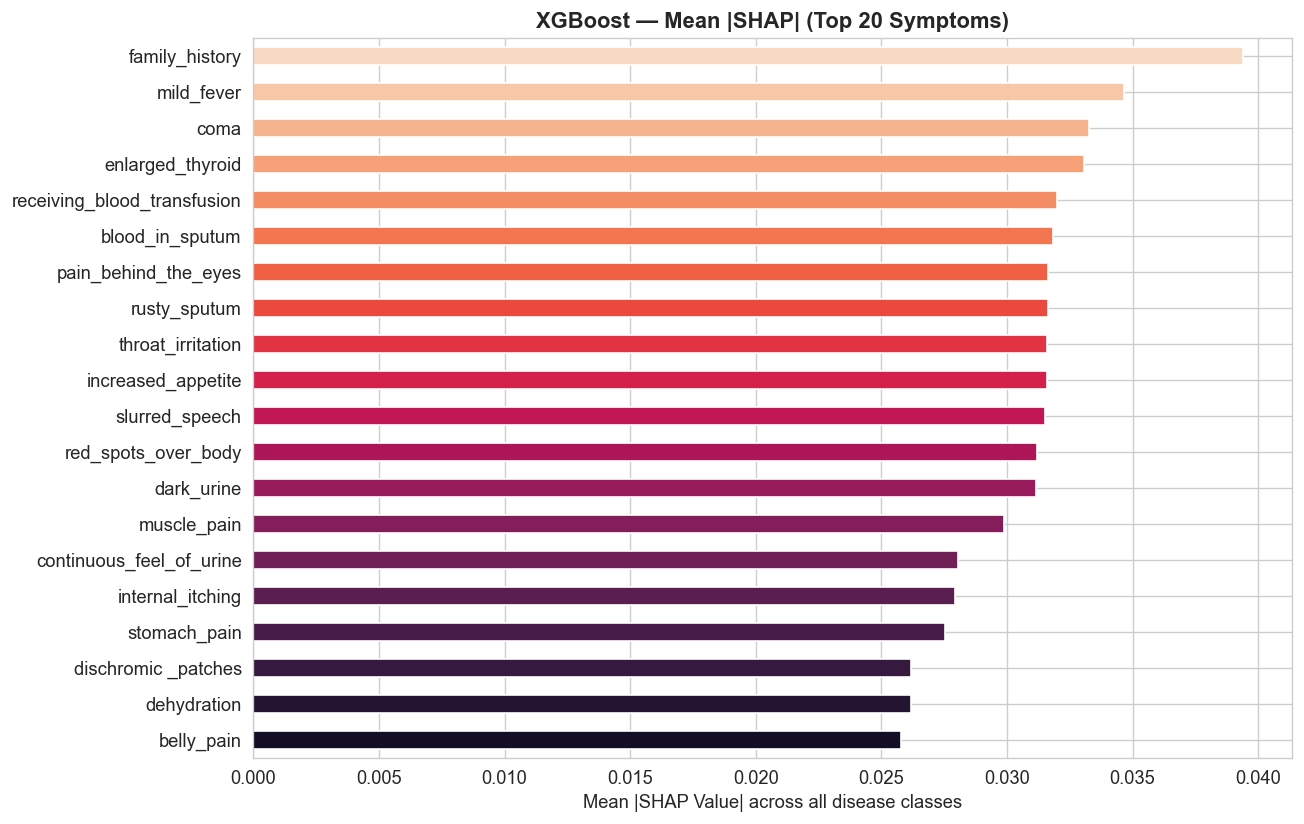

In [33]:
# --- SHAP Explainer + Bar Plot 
xgb_final = xgb_grid.best_estimator_

explainer   = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)

print(f'shap_values type  : {type(shap_values)}')
print(f'shap_values shape : {np.array(shap_values).shape}')

# Handle all possible output shapes from different SHAP versions
sv = np.array(shap_values)

if sv.ndim == 3:
    # Shape (n_samples, n_features, n_classes) — newer SHAP
    mean_shap = np.abs(sv).mean(axis=2).mean(axis=0)
elif sv.ndim == 4:
    # Shape (n_classes, n_samples, n_features) — some versions
    mean_shap = np.abs(sv).mean(axis=0).mean(axis=0)
else:
    # 2D fallback
    mean_shap = np.abs(sv).mean(axis=0)

print(f'mean_shap shape   : {mean_shap.shape}')  # should be (132,)

shap_series = pd.Series(mean_shap, index=FEATURE_COLS).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(11, 7))
shap_series.plot(kind='barh', ax=ax, color=sns.color_palette('rocket', 20))
ax.set_title('XGBoost — Mean |SHAP| (Top 20 Symptoms)', fontweight='bold')
ax.set_xlabel('Mean |SHAP Value| across all disease classes')
plt.tight_layout()
plt.savefig('../results/aakash_results/xgb_shap_bar.png', bbox_inches='tight')
plt.show()

<Figure size 1440x960 with 0 Axes>

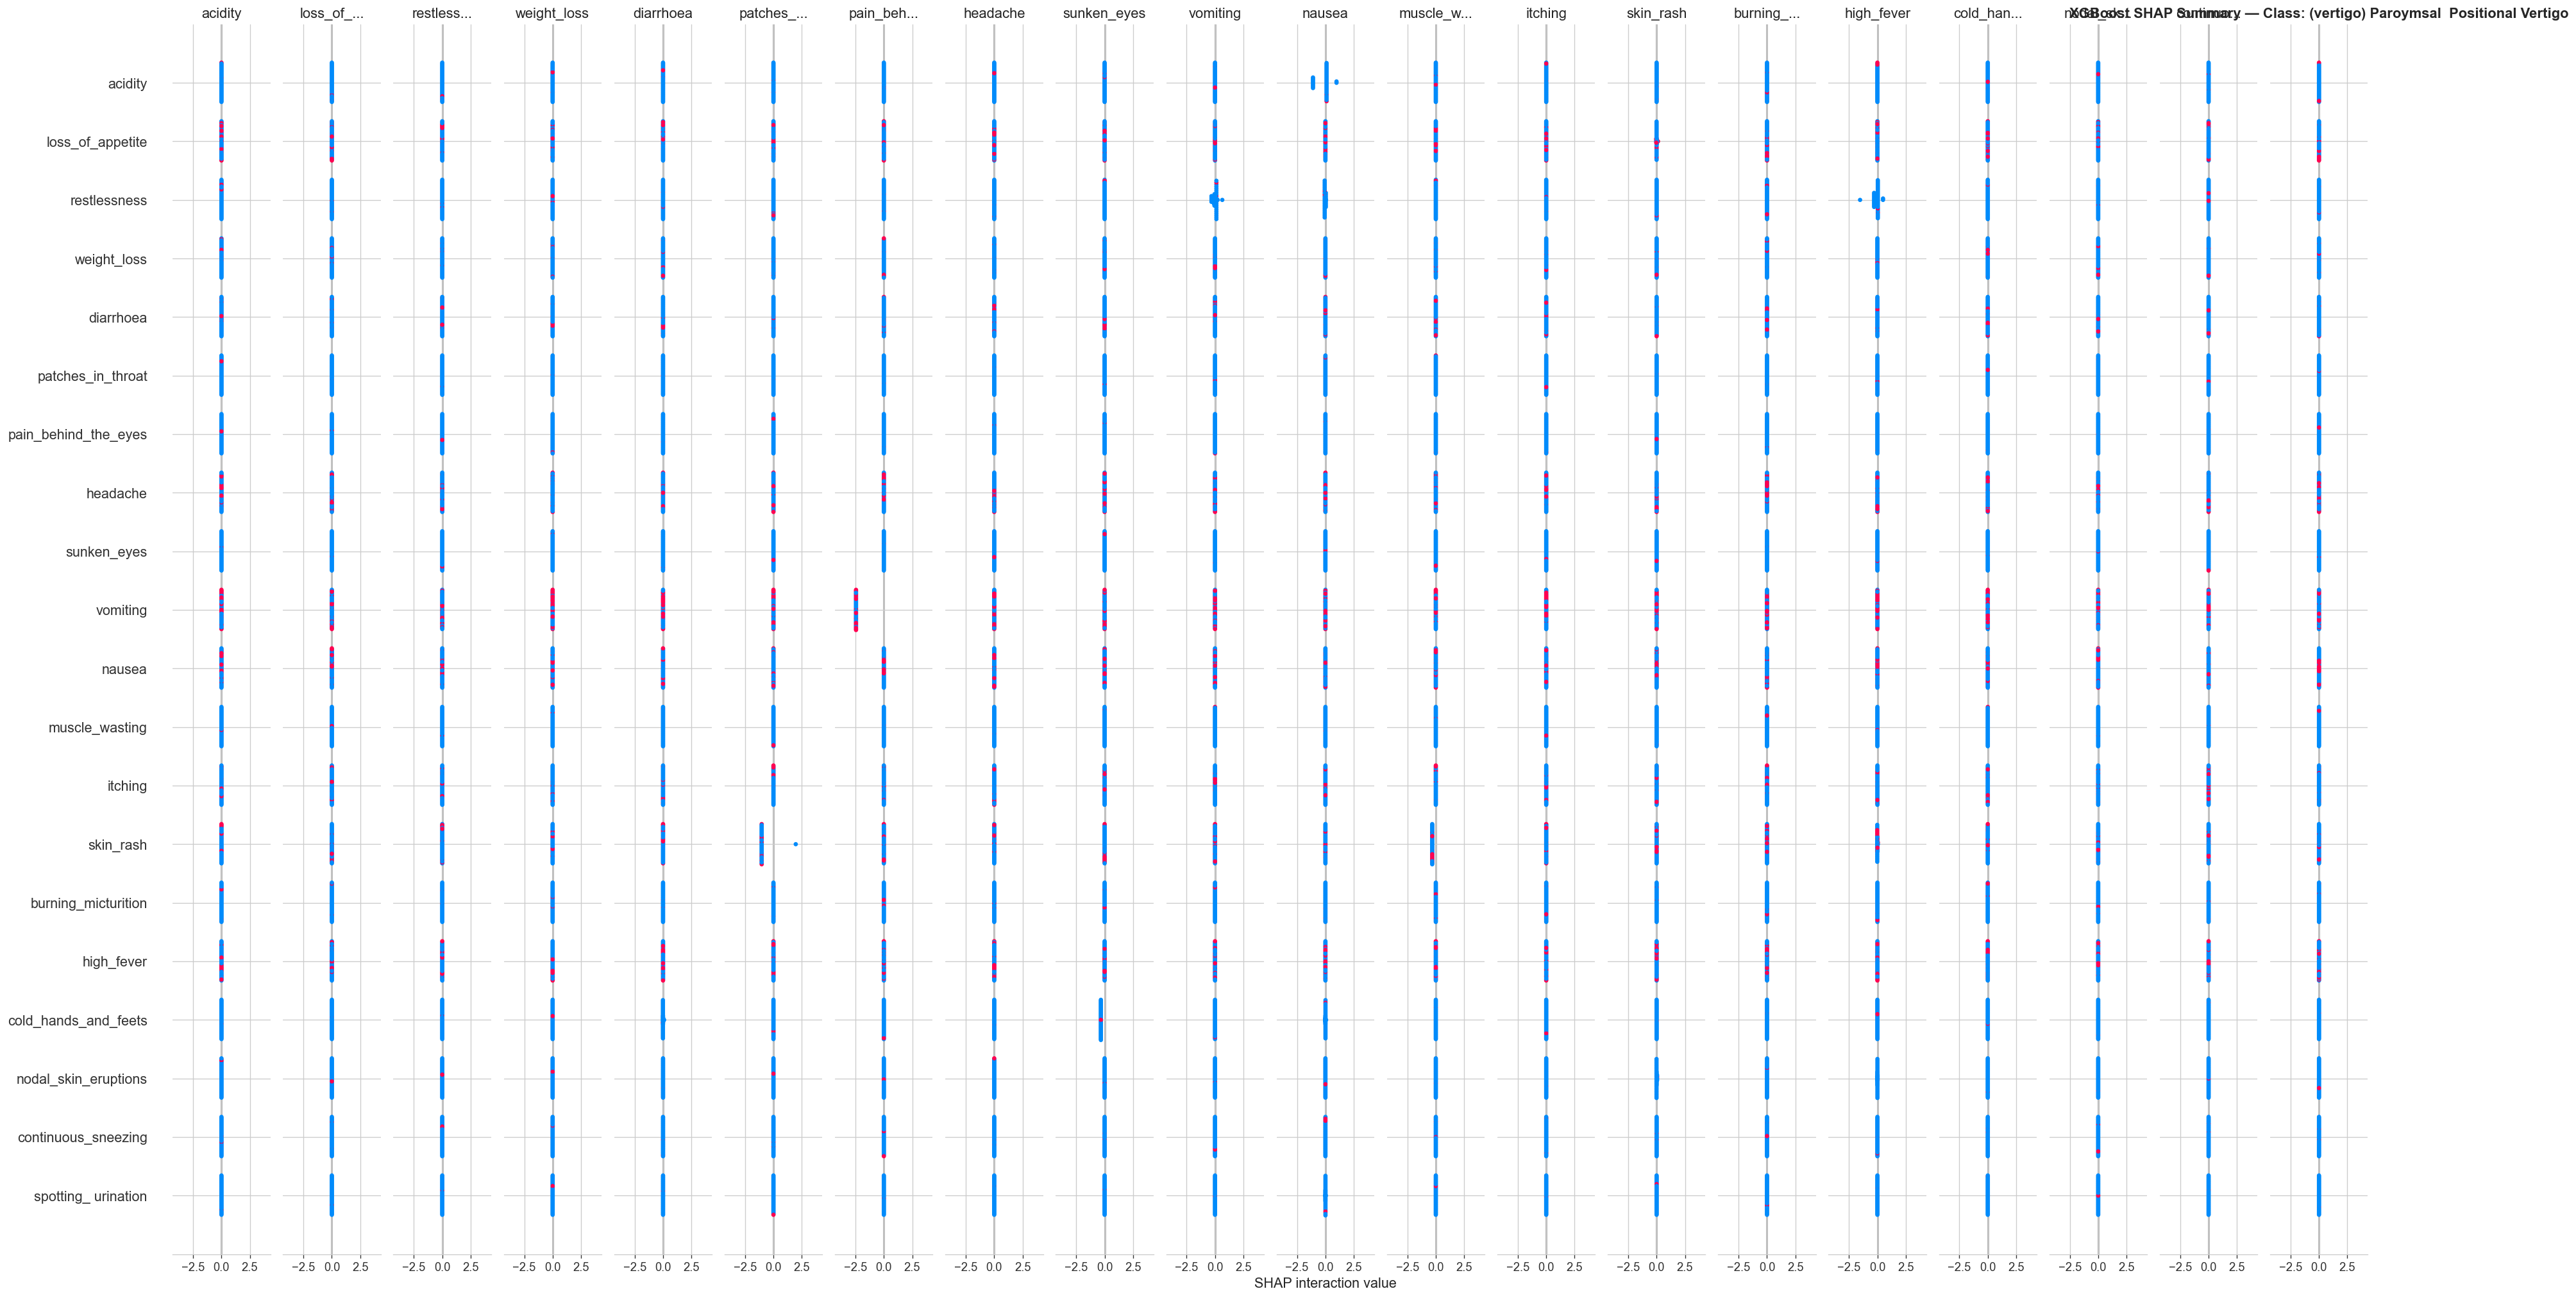

In [34]:
# SHAP summary beeswarm plot
plt.figure(figsize=(12, 8))
if isinstance(shap_values, list):
    # Use class 0 for illustration; replace index to inspect a specific disease
    shap.summary_plot(shap_values[0], X_test,
                      feature_names=FEATURE_COLS, max_display=20, show=False)
else:
    shap.summary_plot(shap_values, X_test,
                      feature_names=FEATURE_COLS, max_display=20, show=False)
plt.title(f'XGBoost SHAP Summary — Class: {le.classes_[0]}', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/aakash_results/xgb_shap_summary.png', bbox_inches='tight')
plt.show()

---
## 9. Deep-Dive: KNN
### 9.1 Choosing K — Accuracy vs K curve

In [35]:
k_range      = range(1, 26)
k_cv_scores  = []
k_test_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    cv_res = cross_validate(knn, X_train, y_train, cv=CV,
                            scoring='f1_macro', n_jobs=-1)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    k_cv_scores.append(cv_res['test_score'].mean())
    k_test_scores.append(f1_score(y_test, y_pred_k, average='macro'))
    print(f'  k={k:2d} | CV F1: {k_cv_scores[-1]*100:.2f}%  Test F1: {k_test_scores[-1]*100:.2f}%')

best_k = list(k_range)[np.argmax(k_cv_scores)]
print(f'\nBest k by CV Macro F1: k={best_k}')

  k= 1 | CV F1: 100.00%  Test F1: 100.00%
  k= 2 | CV F1: 100.00%  Test F1: 100.00%
  k= 3 | CV F1: 100.00%  Test F1: 100.00%
  k= 4 | CV F1: 100.00%  Test F1: 100.00%
  k= 5 | CV F1: 100.00%  Test F1: 100.00%
  k= 6 | CV F1: 100.00%  Test F1: 100.00%
  k= 7 | CV F1: 100.00%  Test F1: 100.00%
  k= 8 | CV F1: 100.00%  Test F1: 100.00%
  k= 9 | CV F1: 100.00%  Test F1: 100.00%
  k=10 | CV F1: 100.00%  Test F1: 100.00%
  k=11 | CV F1: 100.00%  Test F1: 100.00%
  k=12 | CV F1: 100.00%  Test F1: 100.00%
  k=13 | CV F1: 100.00%  Test F1: 100.00%
  k=14 | CV F1: 100.00%  Test F1: 100.00%
  k=15 | CV F1: 100.00%  Test F1: 100.00%
  k=16 | CV F1: 100.00%  Test F1: 100.00%
  k=17 | CV F1: 100.00%  Test F1: 100.00%
  k=18 | CV F1: 100.00%  Test F1: 100.00%
  k=19 | CV F1: 100.00%  Test F1: 100.00%
  k=20 | CV F1: 100.00%  Test F1: 100.00%
  k=21 | CV F1: 100.00%  Test F1: 100.00%
  k=22 | CV F1: 100.00%  Test F1: 100.00%
  k=23 | CV F1: 100.00%  Test F1: 100.00%
  k=24 | CV F1: 100.00%  Test F1: 

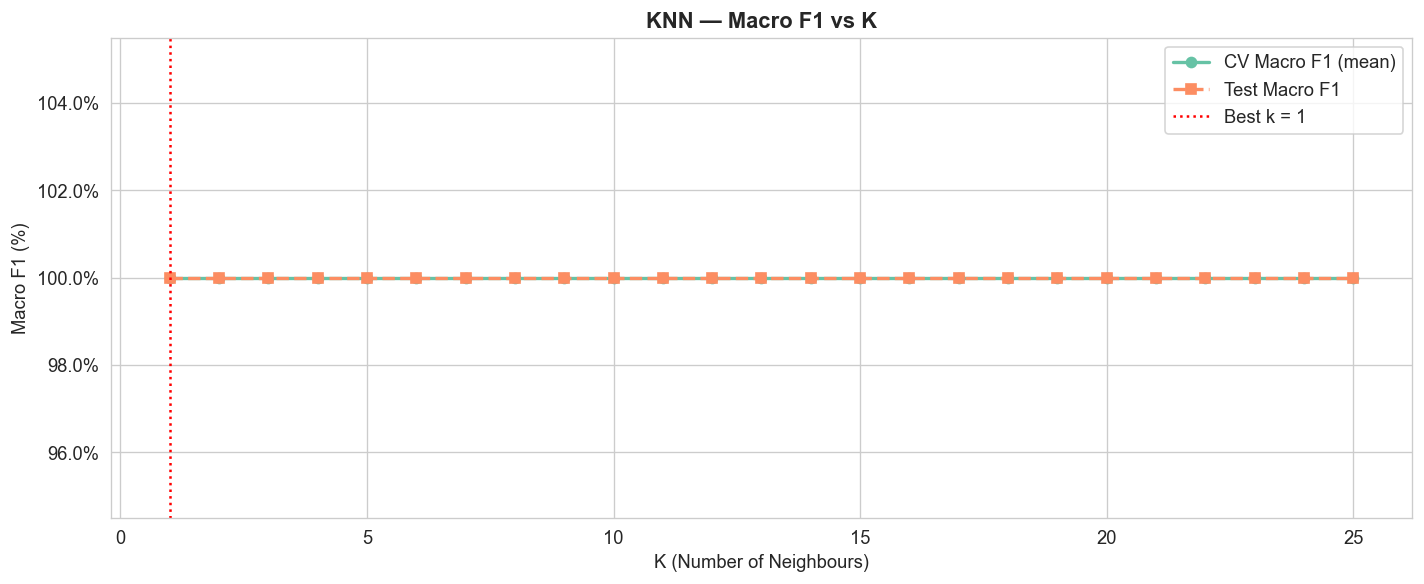

In [36]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_range, [s * 100 for s in k_cv_scores],
        'o-', color=PALETTE[0], label='CV Macro F1 (mean)', linewidth=2)
ax.plot(k_range, [s * 100 for s in k_test_scores],
        's--', color=PALETTE[1], label='Test Macro F1', linewidth=2)
ax.axvline(best_k, color='red', linestyle=':', linewidth=1.5,
           label=f'Best k = {best_k}')
ax.set_xlabel('K (Number of Neighbours)')
ax.set_ylabel('Macro F1 (%)')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))
ax.set_title('KNN — Macro F1 vs K', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../results/aakash_results/knn_k_curve.png', bbox_inches='tight')
plt.show()

### 9.2 Distance Metric Comparison

  euclidean    | Acc: 100.00%  Macro F1: 100.00%
  manhattan    | Acc: 100.00%  Macro F1: 100.00%
  hamming      | Acc: 100.00%  Macro F1: 100.00%
  jaccard      | Acc: 100.00%  Macro F1: 100.00%


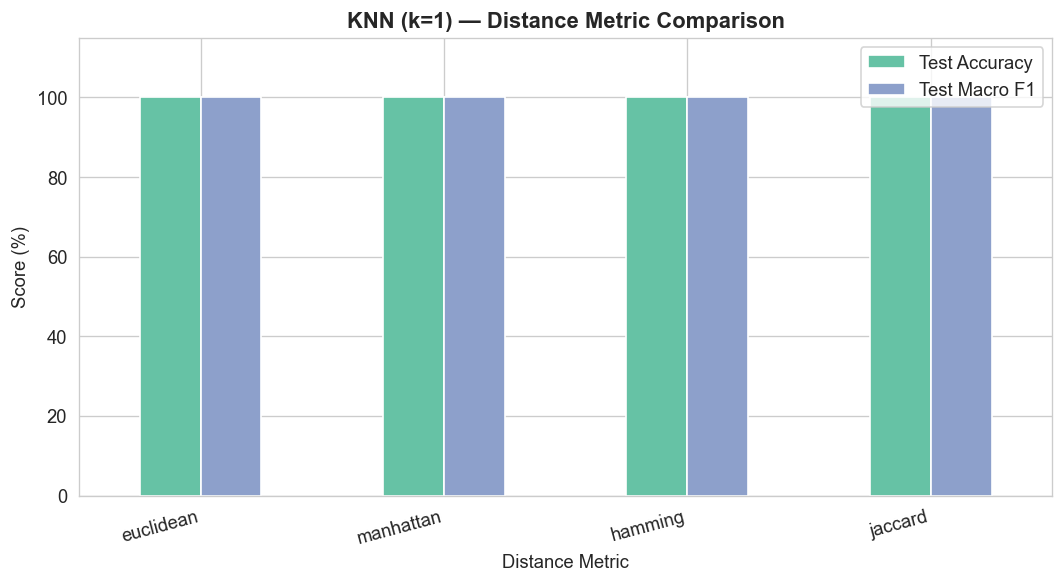

In [37]:
metrics_to_try = ['euclidean', 'manhattan', 'hamming', 'jaccard']
metric_results = []

for metric in metrics_to_try:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric, n_jobs=-1)
    knn.fit(X_train, y_train)
    y_pred_m = knn.predict(X_test)
    metric_results.append({
        'Distance Metric' : metric,
        'Test Accuracy'   : accuracy_score(y_test, y_pred_m) * 100,
        'Test Macro F1'   : f1_score(y_test, y_pred_m, average='macro') * 100,
    })
    print(f'  {metric:12s} | Acc: {metric_results[-1]["Test Accuracy"]:.2f}%  Macro F1: {metric_results[-1]["Test Macro F1"]:.2f}%')

metric_df = pd.DataFrame(metric_results).set_index('Distance Metric')

fig, ax = plt.subplots(figsize=(9, 5))
metric_df.plot(kind='bar', ax=ax,
               color=[PALETTE[0], PALETTE[2]], edgecolor='white')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.set_title(f'KNN (k={best_k}) — Distance Metric Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../results/aakash_results/knn_metric_comparison.png', bbox_inches='tight')
plt.show()

### 9.3 KNN — Symptom Importance via Permutation

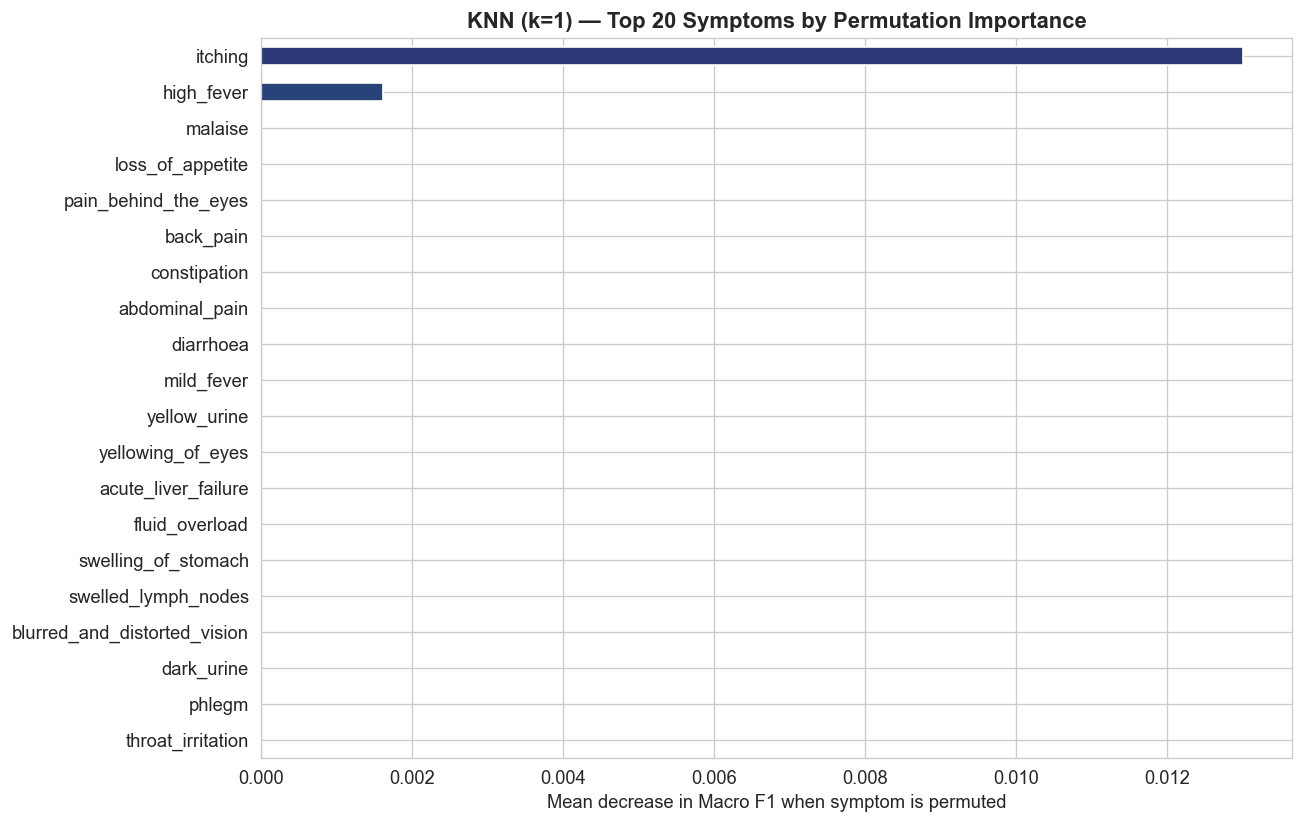

In [38]:
from sklearn.inspection import permutation_importance

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', n_jobs=-1)
knn_best.fit(X_train, y_train)

perm_result = permutation_importance(
    knn_best, X_test, y_test,
    scoring='f1_macro', n_repeats=10,
    random_state=42, n_jobs=-1
)

perm_series = pd.Series(
    perm_result.importances_mean, index=FEATURE_COLS
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(11, 7))
perm_series.plot(kind='barh', ax=ax, color=sns.color_palette('crest', 20))
ax.set_title(f'KNN (k={best_k}) — Top 20 Symptoms by Permutation Importance',
             fontweight='bold')
ax.set_xlabel('Mean decrease in Macro F1 when symptom is permuted')
plt.tight_layout()
plt.savefig('../results/aakash_results/knn_permutation_importance.png', bbox_inches='tight')
plt.show()

---
## 10. Confusion Matrix — Per Active Model

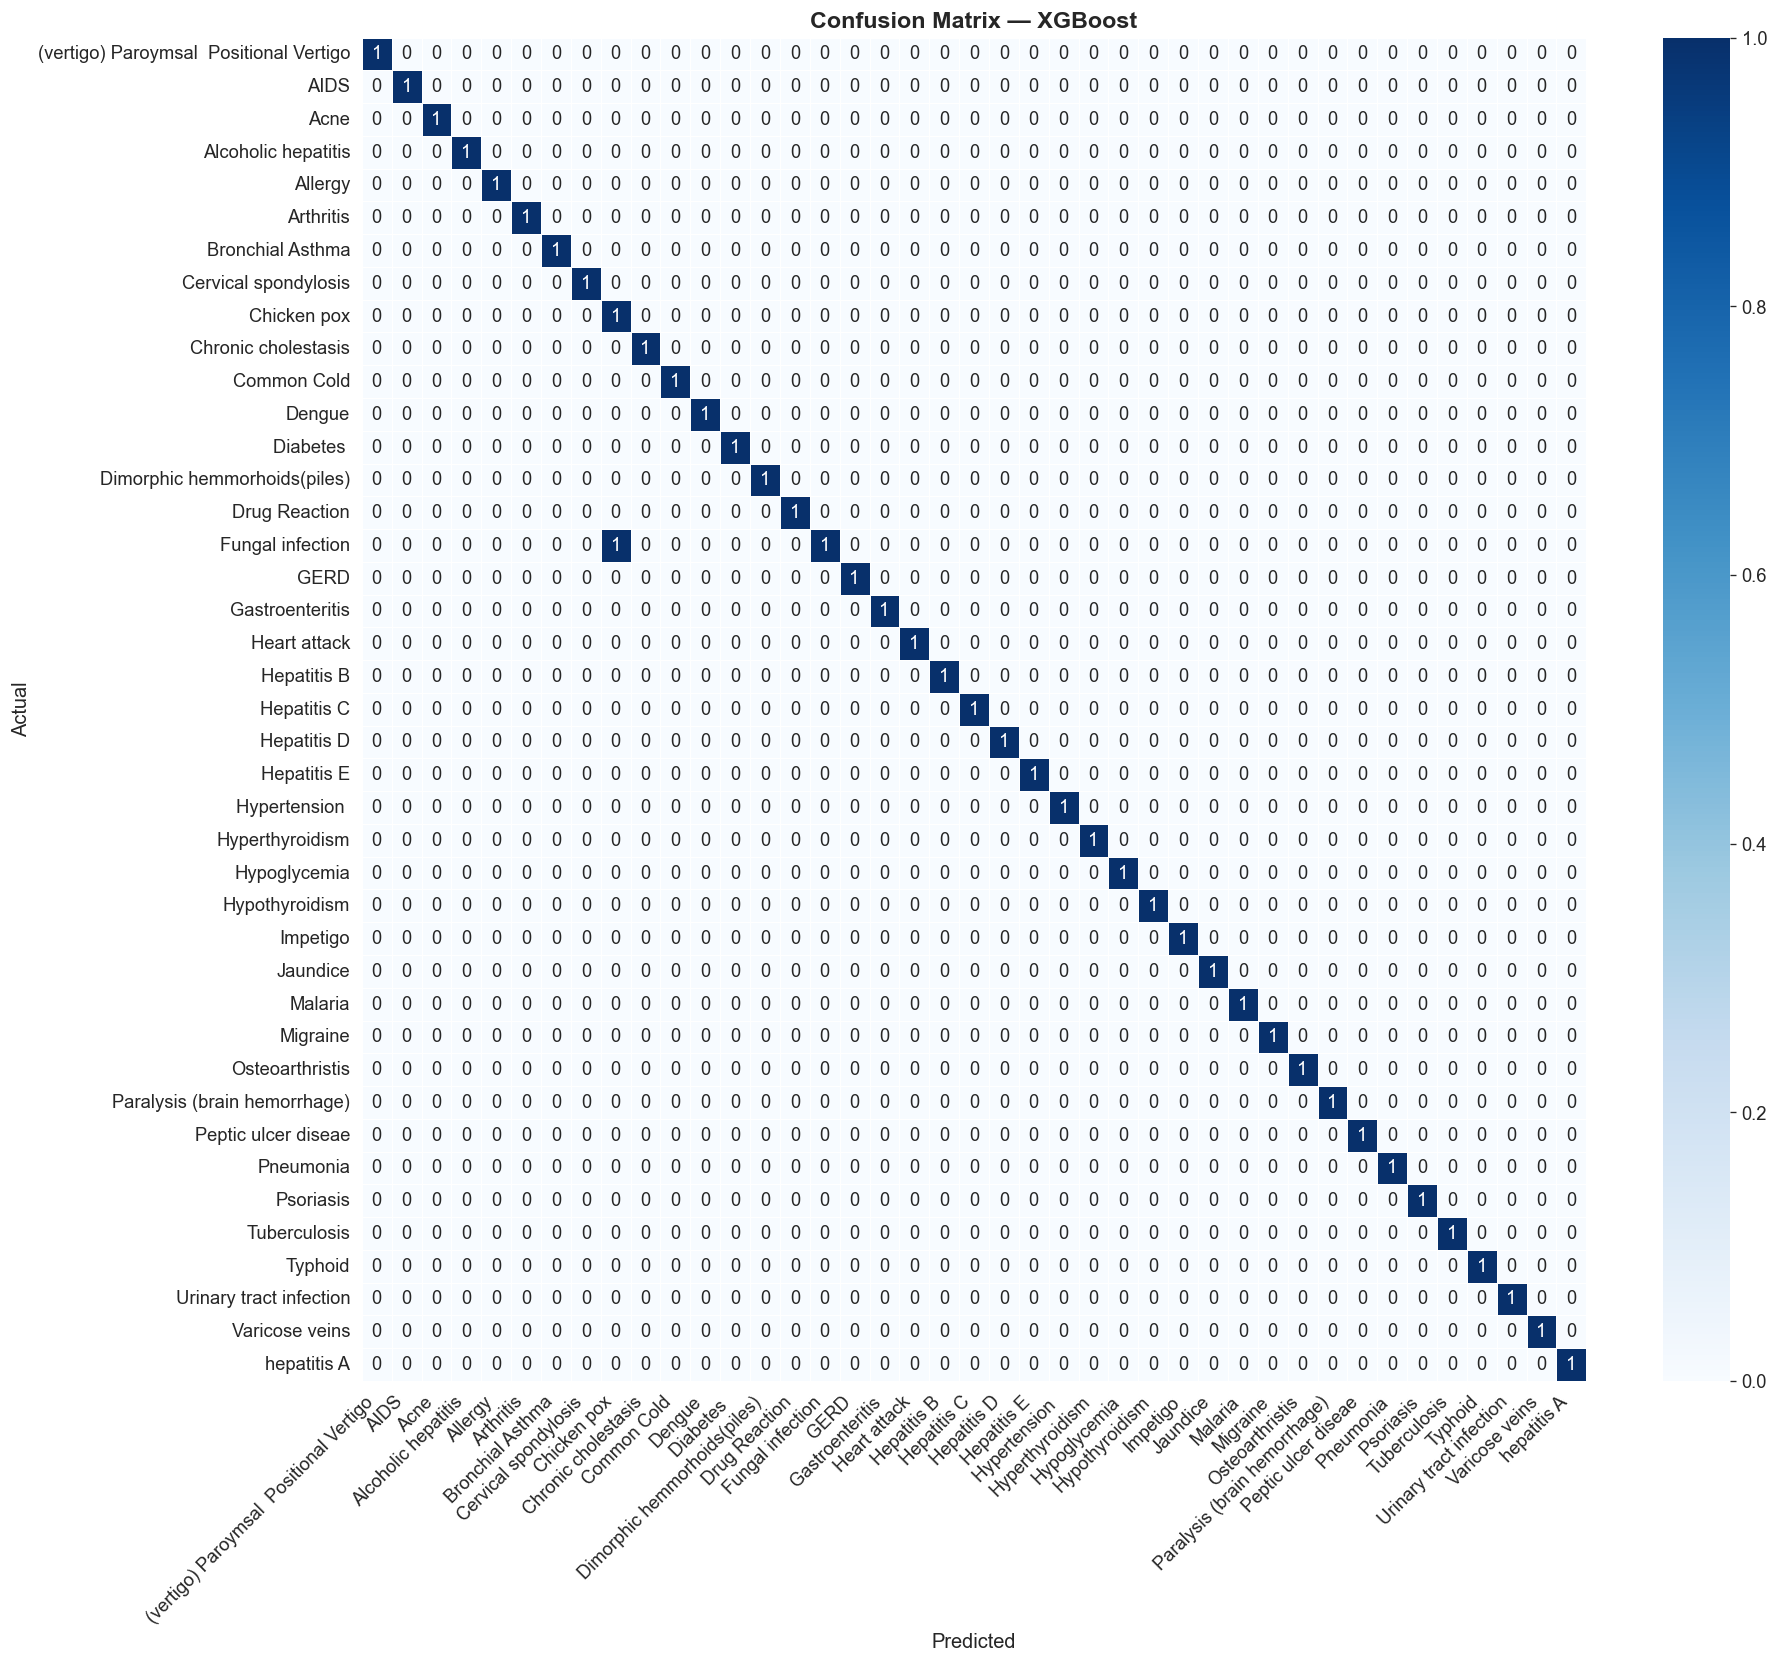

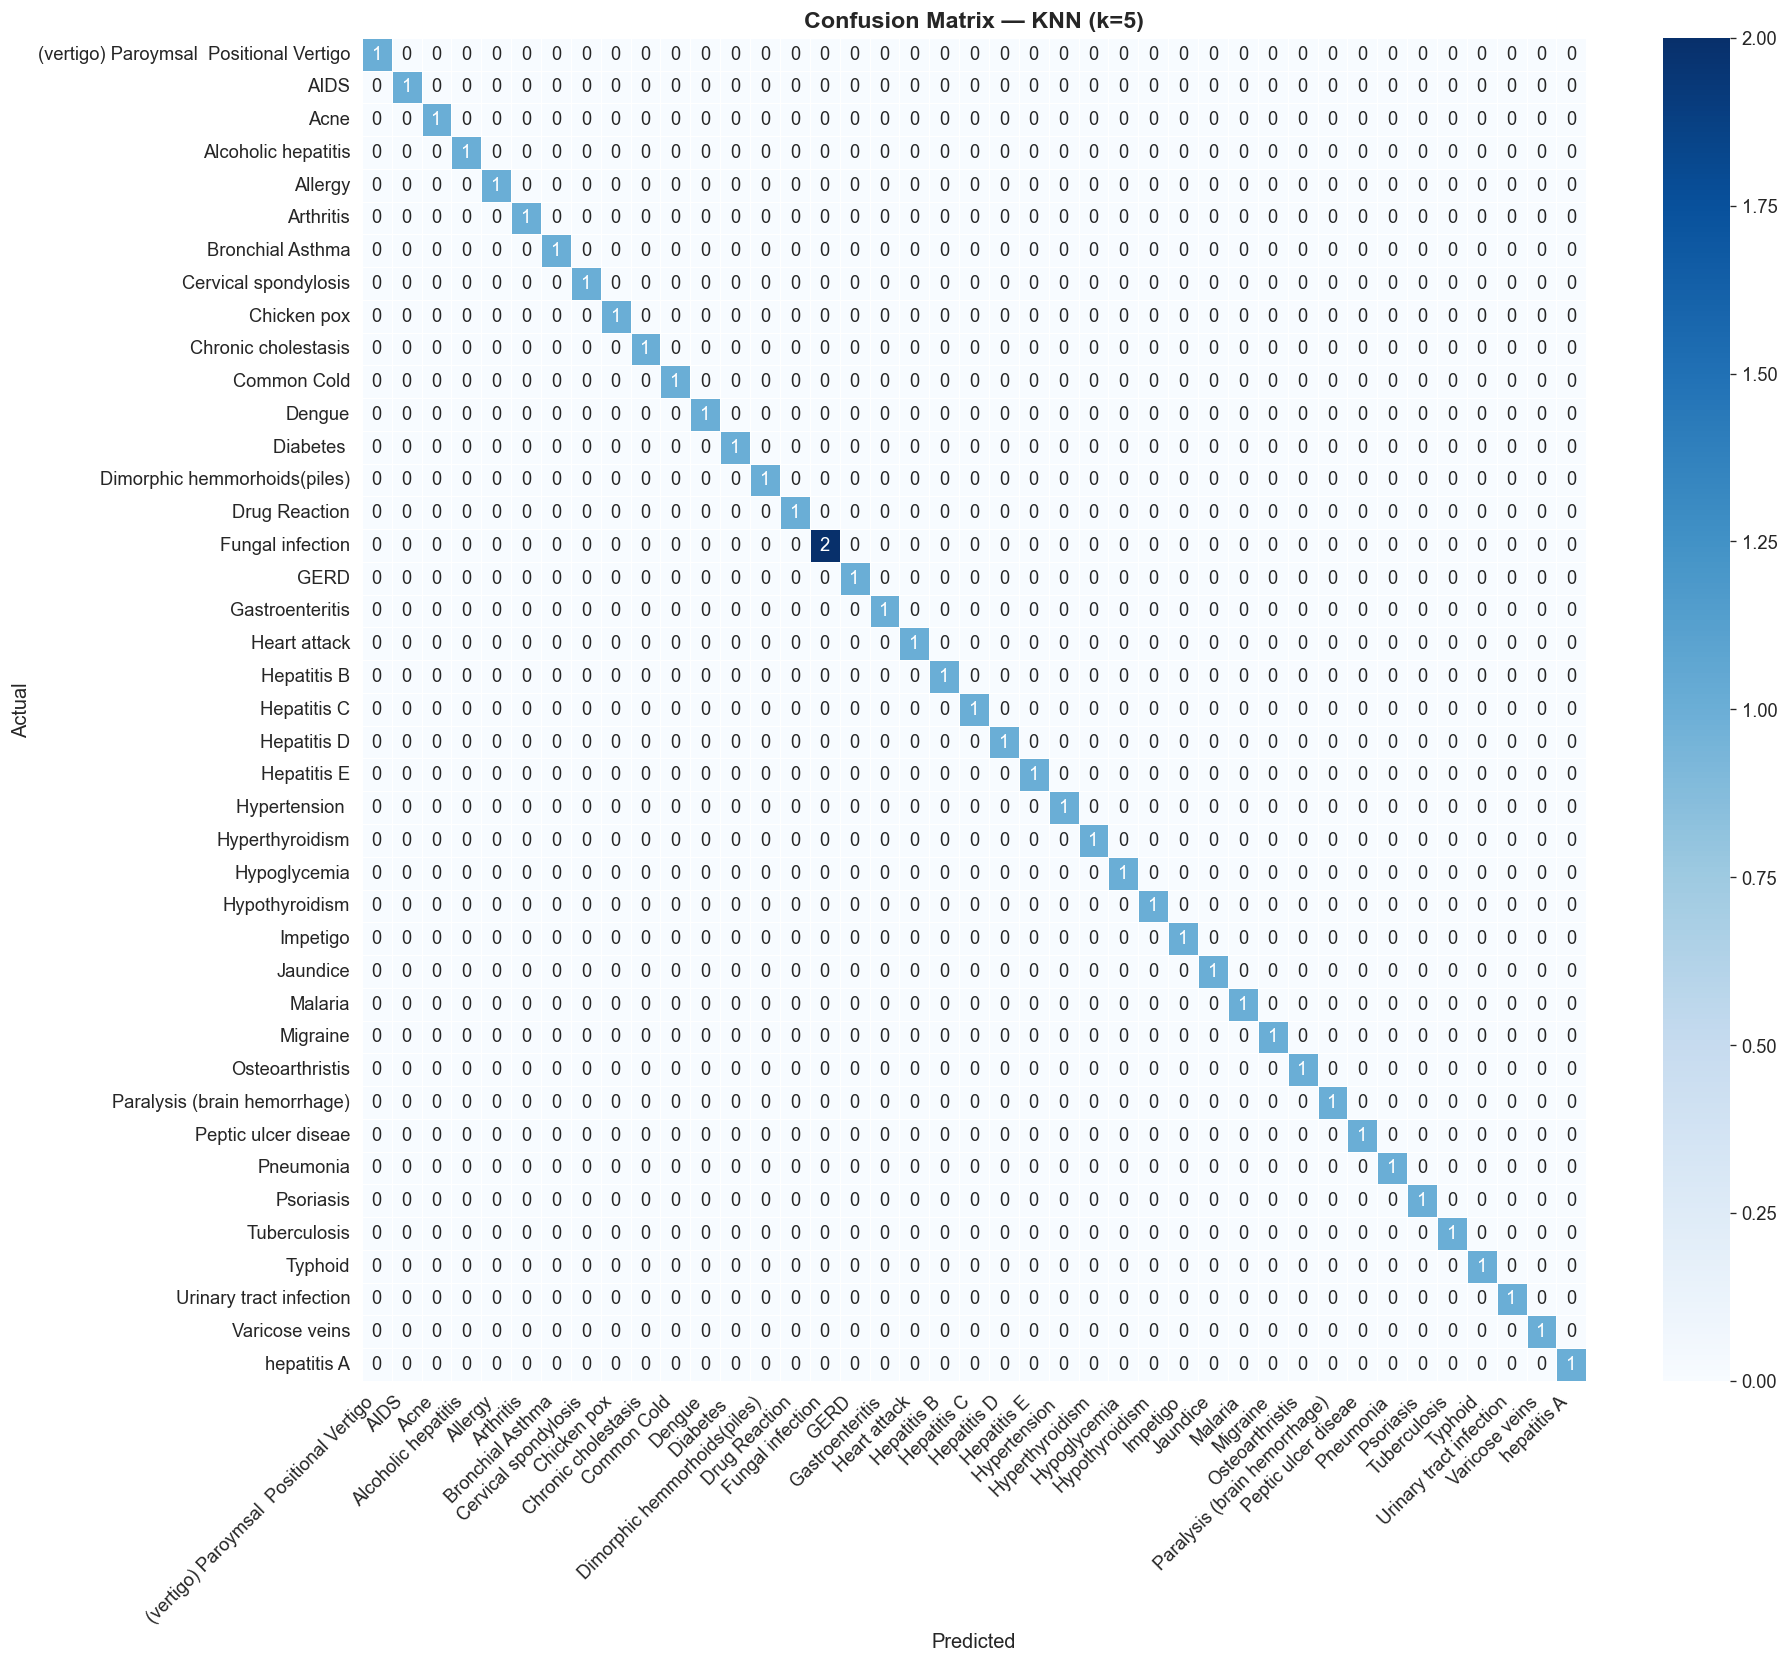

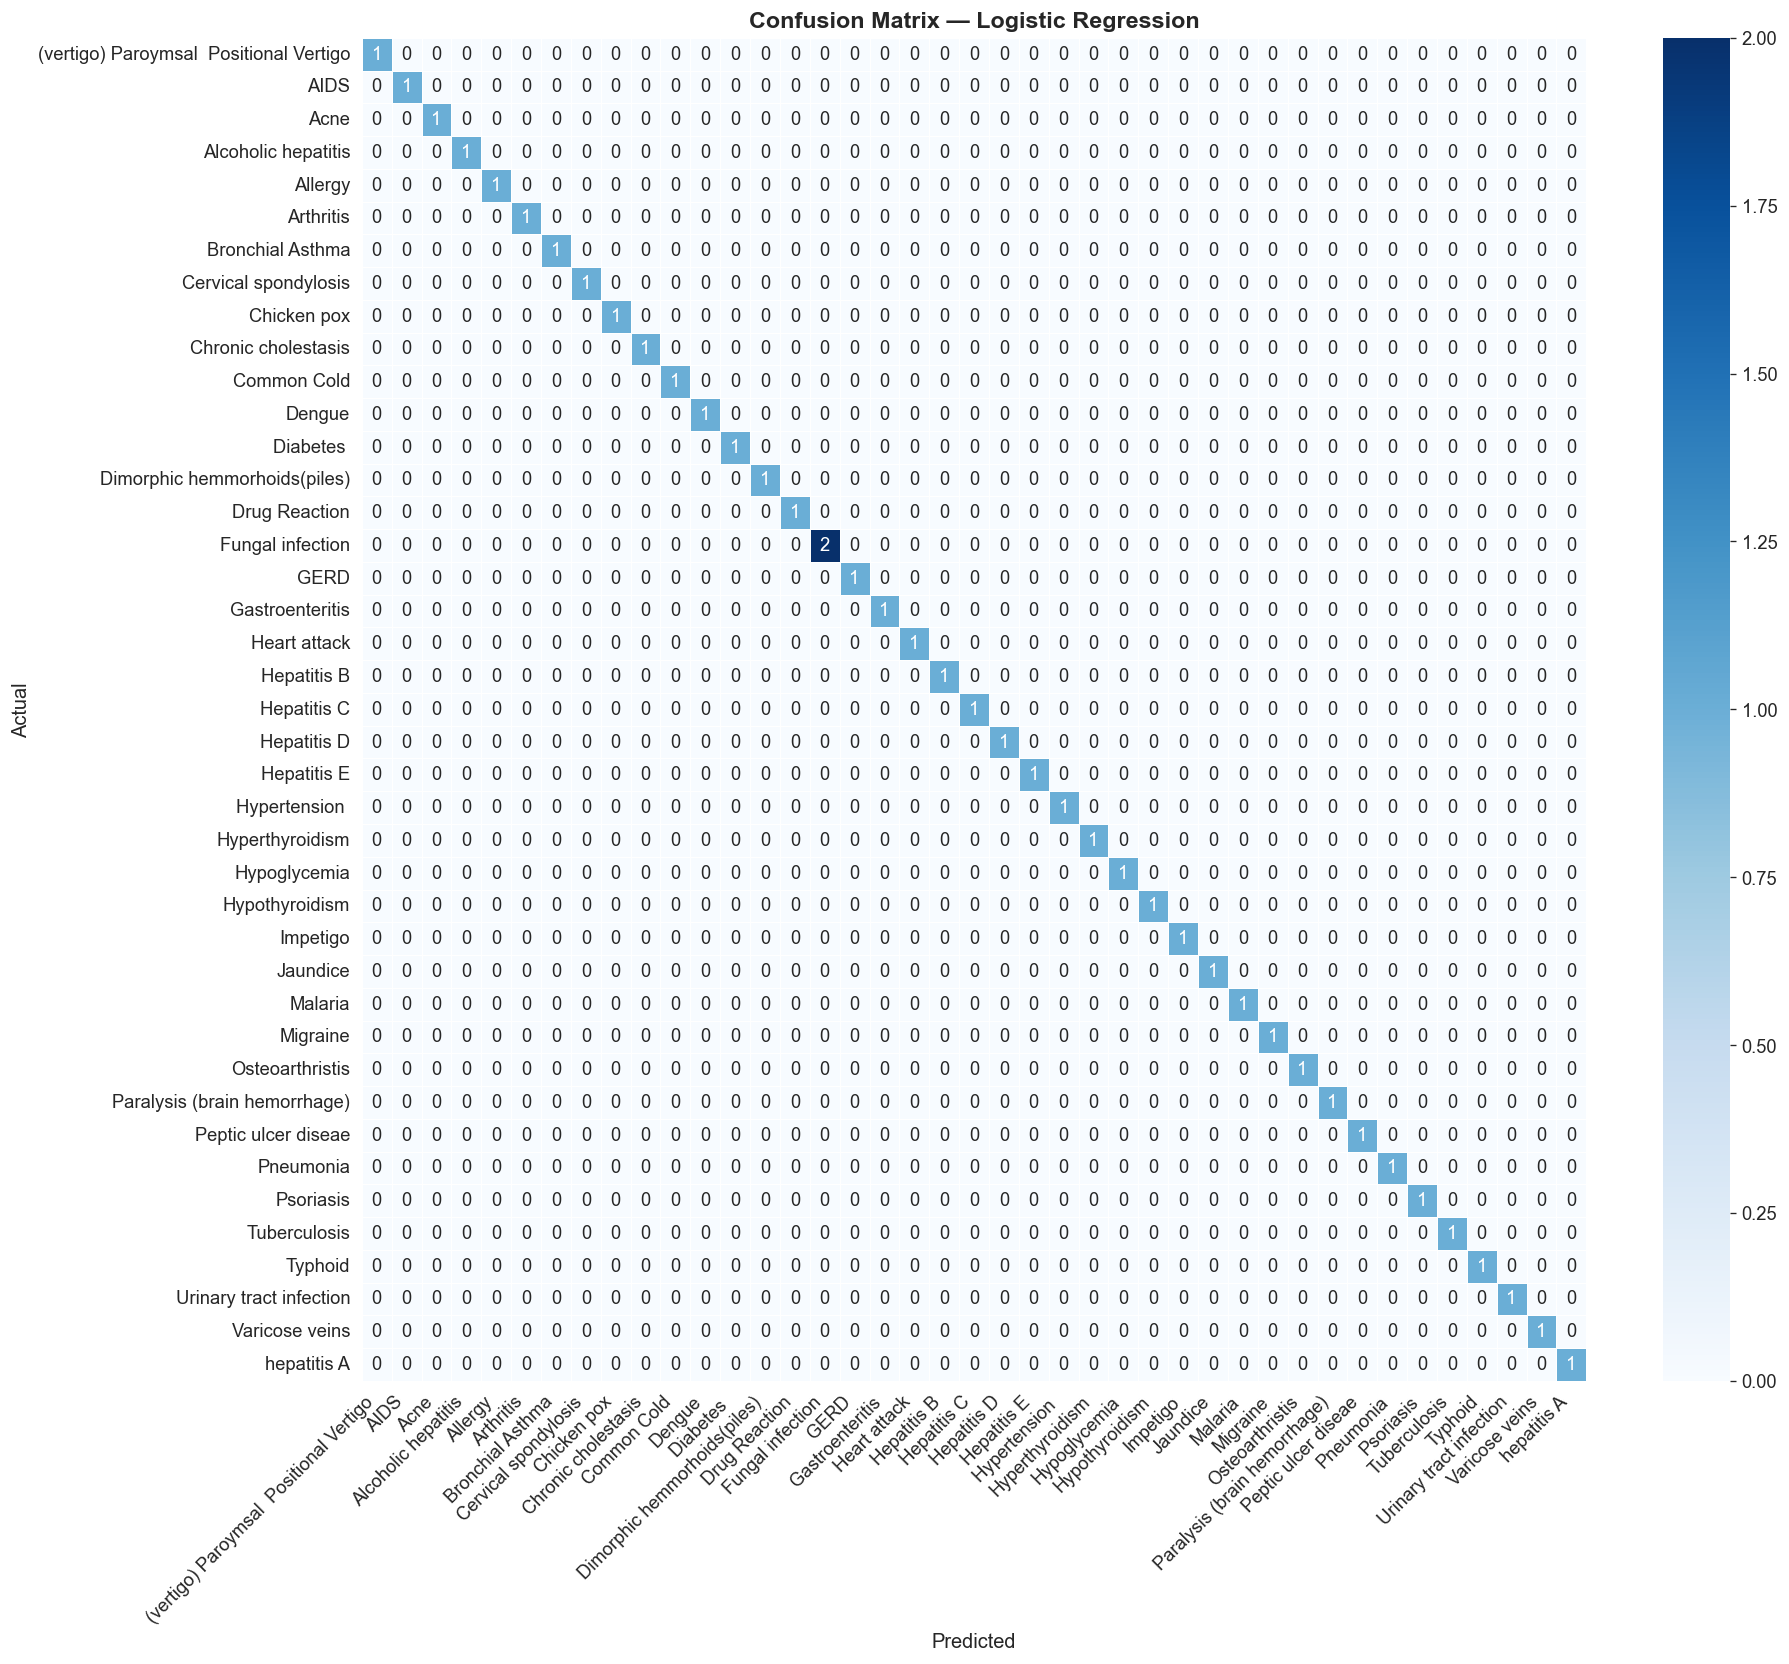

In [39]:
# Retrieve stored predictions from all_results
pred_map = {r['Model']: r['_y_pred'] for r in all_results}

for name, y_pred in pred_map.items():
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_, yticklabels=le.classes_,
        linewidths=0.3, ax=ax
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    safe_name = name.replace(' ', '_').replace('/', '_')
    plt.savefig(f'../results/aakash_results/confusion_matrix_{safe_name}.png', bbox_inches='tight')
    plt.show()

## 11. Final Summary

In [40]:
print('=' * 65)
print('  FINAL SUMMARY')
print('=' * 65)

for col in ['Test Accuracy', 'Test Macro F1', 'CV Macro F1']:
    best = results_df[col].idxmax()
    print(f'  Best by {col:<22}: {best}  ({results_df.loc[best, col]*100:.2f}%)')

fastest = results_df['Train Time (s)'].idxmin()
print(f'  Fastest to train          : {fastest}  ({results_df.loc[fastest, "Train Time (s)"]}s)')

print('\n  XGBoost best params       :', xgb_grid.best_params_)
print(f'  KNN best K                : k={best_k}')
print(f'  Active models             : {list(results_df.index)}')
print('\n  All output charts saved to ../results/aakash_results/')
print('=' * 65)

  FINAL SUMMARY
  Best by Test Accuracy         : KNN (k=5)  (100.00%)
  Best by Test Macro F1         : KNN (k=5)  (100.00%)
  Best by CV Macro F1           : KNN (k=5)  (100.00%)
  Fastest to train          : KNN (k=5)  (0.007s)

  XGBoost best params       : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
  KNN best K                : k=1
  Active models             : ['KNN (k=5)', 'Logistic Regression', 'XGBoost']

  All output charts saved to ../results/aakash_results/
